# Laboratorio 4 Parte 2
## Modelos usando datos geoespaciales

Link del repositorio: https://github.com/Ninaswiftie09/Data_Science/tree/Laboratorio4_Parte2


## 1. Importaciones y conexión con el proyecto



In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from config import (
    DATASET_ML_PATH,
    LAGOS,
    MUESTRA_ML_POR_FECHA,
    NUBOSIDAD_OFICIAL,
    RANDOM_STATE,
    RESULTADOS_DIR,
    UMBRAL_CYANO_ALTO
)

from funciones import (
    construir_dataset_ml,
    graficar_distribucion_objetivo,
    graficar_eda_ml,
    resumir_dataset_ml
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Proyecto:", project_root)
print("Dataset ML:", DATASET_ML_PATH)
print("Umbral de cianobacteria alta:", UMBRAL_CYANO_ALTO)
print("Máximo por fecha:", MUESTRA_ML_POR_FECHA)

Proyecto: C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science
Dataset ML: C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\dataset_ml_parte2.csv.gz
Umbral de cianobacteria alta: 0.05
Máximo por fecha: 30000


# Ejercicio 1. Preparación de los datos para Machine Learning

La Parte I dejó 3,460,152 píxeles válidos de agua entre los dos lagos. Atitlán aporta 3,052,034 y Amatitlán aporta 408,118. Para que el conjunto sea manejable y para que una fecha no domine solo por tener más píxeles, se toman hasta 30,000 observaciones por lago y fecha. El muestreo conserva la proporción original de la clase alta y baja dentro de cada fecha.

Con las 22 fechas disponibles el conjunto final contiene 660,000 observaciones. Cada fila conserva su longitud, latitud, fecha, lago, bandas espectrales, NDVI, NDWI e índice de cianobacteria.

## 1.1 Construcción del conjunto de datos

Se reutilizan los GeoTIFF descargados en la Parte I. La función aplica la misma máscara de agua y calidad que ya estaba implementada. También elimina valores no finitos antes de crear cada observación.

In [2]:
datos = construir_dataset_ml(
    lagos=LAGOS,
    nubosidad_oficial=NUBOSIDAD_OFICIAL,
    salida_csv=DATASET_ML_PATH,
    umbral_cyano=UMBRAL_CYANO_ALTO,
    max_observaciones_fecha=MUESTRA_ML_POR_FECHA,
    random_state=RANDOM_STATE,
    reutilizar=True
)

print("Forma del conjunto:", datos.shape)
datos.head()

Se reutiliza el conjunto de datos: C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\dataset_ml_parte2.csv.gz


Forma del conjunto: (660000, 21)


,longitud,latitud,fecha,lago,B03,B04,B05,B06,B08,SCL,ndvi,ndwi,cyano,cyano_alta,nubosidad_pct,mes,dia_anio,mes_sin,mes_cos,dia_anio_sin,dia_anio_cos
0,-91.214362,14.736191,2025-01-18,Atitlán,0.0093,0.0017,0.0011,0.0018,0.0033,6,0.320000,0.476190,-0.000578,0,0.02,1,18,0.5,0.866025,0.304115,0.952635
1,-91.192220,14.696073,2025-01-18,Atitlán,0.0092,0.0003,-0.0015,-0.0004,0.0016,6,0.684211,0.703704,-0.001251,0,0.02,1,18,0.5,0.866025,0.304115,0.952635
2,-91.150258,14.673510,2025-01-18,Atitlán,0.0076,0.0004,0.0002,0.0009,0.0010,6,0.428571,0.767442,0.000246,0,0.02,1,18,0.5,0.866025,0.304115,0.952635
3,-91.165204,14.729119,2025-01-18,Atitlán,0.0087,0.0003,-0.0006,-0.0005,0.0005,6,0.250000,0.891304,-0.000473,0,0.02,1,18,0.5,0.866025,0.304115,0.952635
4,-91.230941,14.684080,2025-01-18,Atitlán,0.0111,0.0010,0.0008,0.0005,0.0009,6,-0.052632,0.850000,0.000067,0,0.02,1,18,0.5,0.866025,0.304115,0.952635


## 1.2 Variables incluidas

El conjunto mantiene las coordenadas, la fecha, el lago, las bandas B03, B04, B05, B06 y B08, la clase SCL, NDVI, NDWI y el índice de cianobacteria. También conserva la nubosidad de la fecha y crea variables temporales cíclicas para usarlas después como predictores.

## 1.3 Limpieza aplicada

Se eliminan píxeles con NoData y valores no finitos. También se quitan sombras, nubes, cirros y nieve mediante SCL. Después se usa NDWI mayor que cero para mantener principalmente agua. Finalmente se exige que las bandas necesarias y los índices tengan valores válidos.

El muestreo se hace después de la limpieza. De esta forma cada fila del conjunto representa una observación válida y no se introducen valores artificiales para rellenar datos faltantes.

## 1.4 Cantidad de observaciones, tipos y valores faltantes

In [3]:
resumen_parte1 = pd.read_csv(
    RESULTADOS_DIR / "resumen_indices.csv",
    parse_dates=["fecha"]
)

print("Píxeles válidos antes del muestreo:", f"{resumen_parte1['pixeles_validos'].sum():,}")
print(resumen_parte1.groupby("lago")["pixeles_validos"].sum())
print("Observaciones esperadas después del muestreo:", len(LAGOS) * 11 * MUESTRA_ML_POR_FECHA)

Píxeles válidos antes del muestreo: 3,460,152
lago
Amatitlán     408118
Atitlán      3052034
Name: pixeles_validos, dtype: int64
Observaciones esperadas después del muestreo: 660000


In [4]:
resumen_ml = resumir_dataset_ml(datos)

print("Total de observaciones:", f"{resumen_ml['total']:,}")
print("\nObservaciones por lago")
display(resumen_ml["por_lago"])

print("Observaciones por fecha")
display(resumen_ml["por_fecha"])

print("Tipos y porcentaje de valores faltantes")
display(resumen_ml["faltantes"])

Total de observaciones: 660,000

Observaciones por lago


,lago,observaciones
0,Amatitlán,330000
1,Atitlán,330000


Observaciones por fecha


,lago,fecha,observaciones
0,Amatitlán,2025-01-28,30000
1,Amatitlán,2025-04-15,30000
2,Amatitlán,2025-04-28,30000
3,Amatitlán,2025-11-24,30000
4,Amatitlán,2026-01-08,30000
5,Amatitlán,2026-02-02,30000
6,Amatitlán,2026-02-07,30000
7,Amatitlán,2026-03-29,30000
8,Amatitlán,2026-04-13,30000
9,Amatitlán,2026-04-28,30000


Tipos y porcentaje de valores faltantes


,variable,tipo,faltantes_pct
0,longitud,float64,0.0
1,latitud,float64,0.0
2,fecha,datetime64[ns],0.0
3,lago,object,0.0
4,B03,float64,0.0
5,B04,float64,0.0
6,B05,float64,0.0
7,B06,float64,0.0
8,B08,float64,0.0
9,SCL,int64,0.0


### Resultado esperado por lago

El límite de 30,000 observaciones por fecha deja 330,000 observaciones para Atitlán y 330,000 para Amatitlán. Esto evita que Atitlán domine el conjunto solo por tener una superficie mayor dentro de los rasters procesados.

## 1.5 Análisis exploratorio

Se revisan las distribuciones de B03, NDVI, NDWI y el índice de cianobacteria. También se muestran las observaciones geográficas de cada lago para comprobar que los puntos están distribuidos sobre el área de agua analizada.

,count,mean,std,min,25%,50%,75%,max
B03,660000.0,0.045454,0.080362,0.001000,0.016200,0.022900,0.054300,1.941800
ndvi,660000.0,-0.080779,0.225024,-0.991968,-0.161290,-0.055480,0.006342,0.977012
ndwi,660000.0,0.417589,0.212389,0.000089,0.264516,0.400000,0.558282,0.996441
cyano,660000.0,0.009402,0.016316,-0.498787,0.000393,0.002427,0.012727,0.719760
longitud,660000.0,-90.882212,0.314816,-91.327001,-91.195402,-90.857015,-90.569407,-90.512020
latitud,660000.0,14.577328,0.121629,14.411766,14.460575,14.544830,14.698587,14.750372
nubosidad_pct,660000.0,2.179091,2.970539,0.010000,0.060000,0.655000,3.570000,13.000000


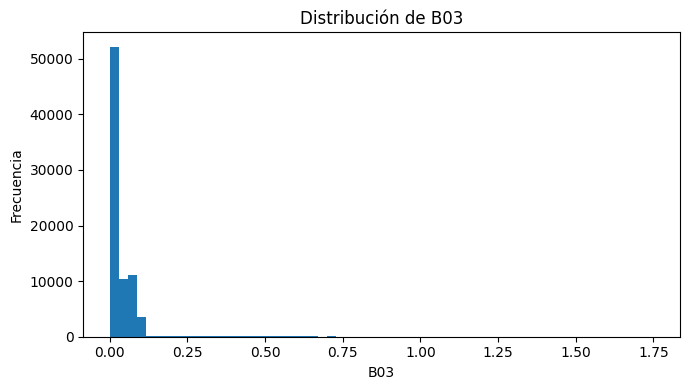

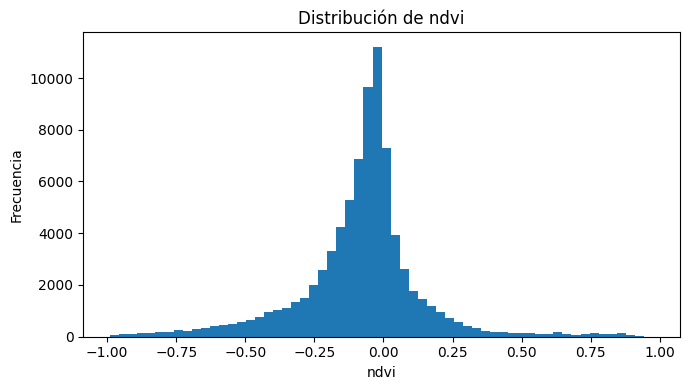

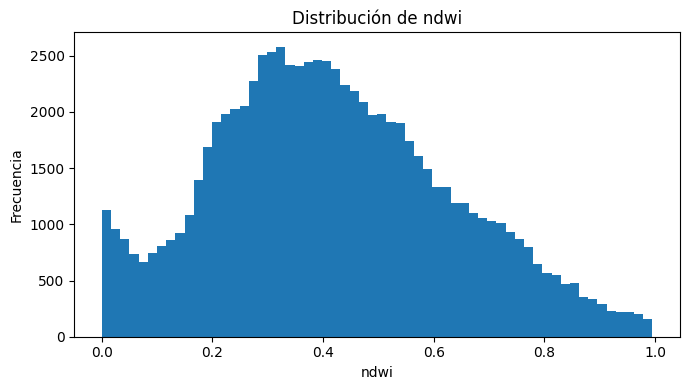

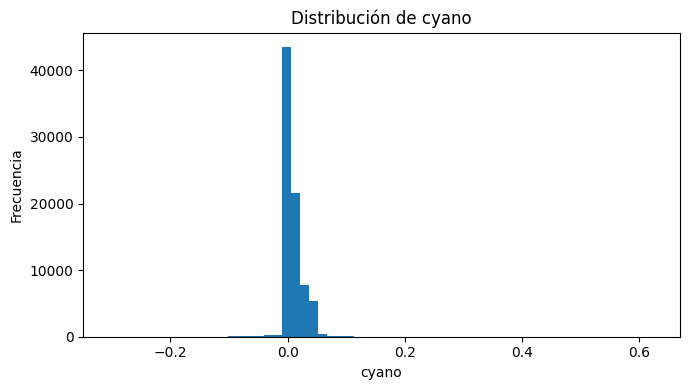

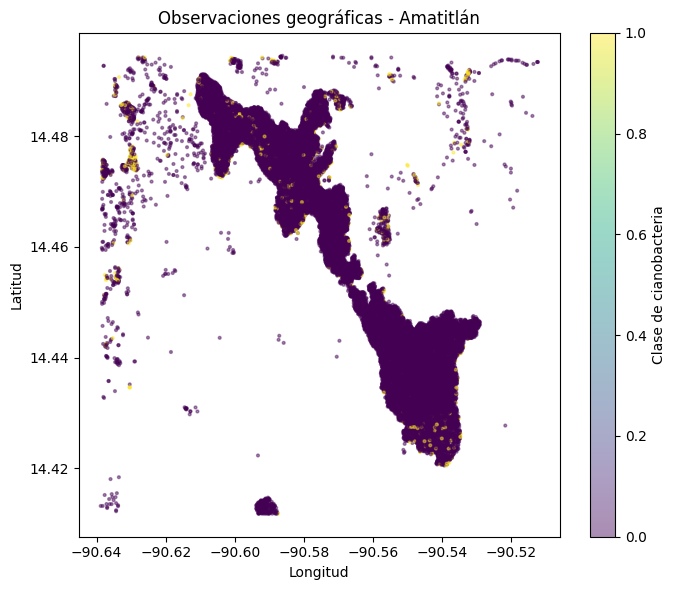

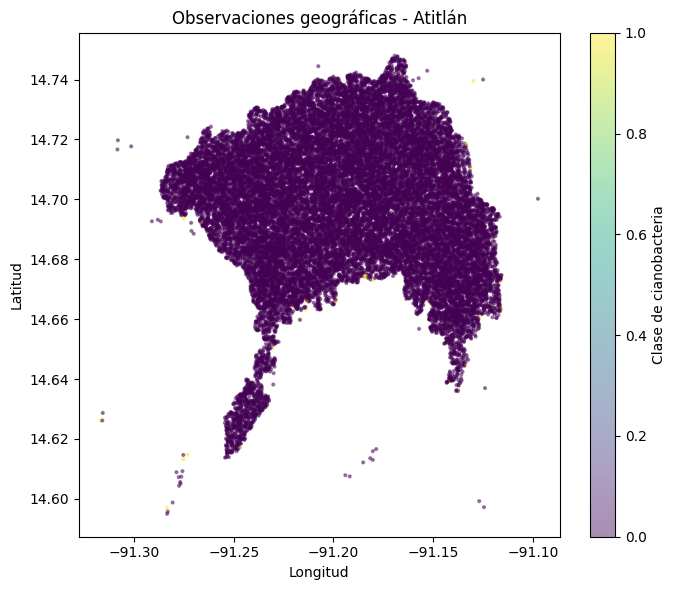

In [5]:
columnas_eda = [
    "B03",
    "ndvi",
    "ndwi",
    "cyano",
    "longitud",
    "latitud",
    "nubosidad_pct"
]

display(datos[columnas_eda].describe().T)

graficar_eda_ml(datos)

## 1.6 Decisiones de preparación

Se mantuvo la resolución y las fechas de la Parte I para que los dos laboratorios sean comparables. No se descargaron nuevas escenas. Se reutilizó la máscara de calidad con SCL y la máscara de agua con NDWI.

El muestreo por fecha reduce el tamaño del conjunto sin dejar fechas con muy poca representación. Además se conserva la proporción de la variable respuesta dentro de cada fecha. Esto es útil porque la clase alta es poco frecuente.

# Ejercicio 2. Construcción de la variable respuesta

La variable cyano_alta usa dos clases.

0 significa ausencia o señal baja.

1 significa señal alta compatible con una floración de mayor intensidad.

## 2.1 Punto de corte

Se usa el mismo Bloom Index de la Parte I. El índice toma el máximo entre MCI y FAI usando B04, B05, B06 y B08. La clase alta se define cuando cyano es mayor que 0.05.

El valor 0.05 se toma del script Maximum Peak Height Bloom Index de Sentinel Hub y CyanoLakes. Ese script usa 0.05 como nivel de referencia para valores asociados con algas flotantes. Este índice no mide directamente concentración de células ni riesgo sanitario. Por eso el corte se usa como una separación espectral operativa entre señal baja y señal alta.

In [6]:
datos["cyano_alta"] = (
    datos["cyano"] > UMBRAL_CYANO_ALTO
).astype("int8")

datos[["cyano", "cyano_alta"]].head()

,cyano,cyano_alta
0,-0.000578,0
1,-0.001251,0
2,0.000246,0
3,-0.000473,0
4,0.000067,0


## 2.2 Justificación científica

Matthews, Bernard y Robertson desarrollaron el enfoque Maximum Peak Height para detectar condiciones tróficas, dominancia de cianobacteria y acumulaciones superficiales en aguas interiores. El script de Sentinel Hub adapta ese enfoque a Sentinel-2 y combina MCI con FAI.

La literatura también muestra que un único umbral espectral no es universal para todos los lagos. Las condiciones atmosféricas, la calidad del agua y la geometría de observación pueden cambiar el valor óptimo. Por eso 0.05 se usa aquí como criterio reproducible para este laboratorio y no como una concentración ambiental universal.

## 2.3 Distribución de la respuesta

Distribución global


,cyano_alta,observaciones,porcentaje
0,0,651969,98.783182
1,1,8031,1.216818


Distribución por lago


,lago,cyano_alta,observaciones,porcentaje
0,Amatitlán,0,322415,97.701515
1,Amatitlán,1,7585,2.298485
2,Atitlán,0,329554,99.864848
3,Atitlán,1,446,0.135152


Distribución por fecha


,lago,fecha,cyano_alta,observaciones,porcentaje
0,Amatitlán,2025-01-28,0,29630,98.766667
1,Amatitlán,2025-01-28,1,370,1.233333
2,Amatitlán,2025-04-15,0,29675,98.916667
3,Amatitlán,2025-04-15,1,325,1.083333
4,Amatitlán,2025-04-28,0,29676,98.920000
5,Amatitlán,2025-04-28,1,324,1.080000
6,Amatitlán,2025-11-24,0,29557,98.523333
7,Amatitlán,2025-11-24,1,443,1.476667
8,Amatitlán,2026-01-08,0,29622,98.740000
9,Amatitlán,2026-01-08,1,378,1.260000


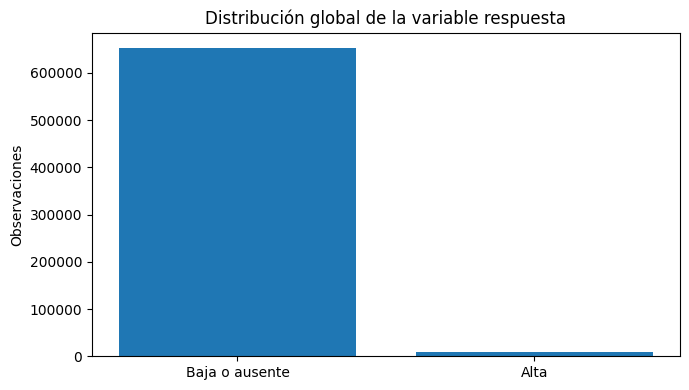

In [7]:
respuesta_global = (
    datos["cyano_alta"]
    .value_counts()
    .sort_index()
    .rename_axis("cyano_alta")
    .reset_index(name="observaciones")
)

respuesta_global["porcentaje"] = (
    respuesta_global["observaciones"]
    / len(datos)
    * 100
)

print("Distribución global")
display(respuesta_global)

respuesta_lago = (
    datos
    .groupby(["lago", "cyano_alta"])
    .size()
    .rename("observaciones")
    .reset_index()
)

respuesta_lago["porcentaje"] = (
    respuesta_lago["observaciones"]
    / respuesta_lago.groupby("lago")["observaciones"].transform("sum")
    * 100
)

print("Distribución por lago")
display(respuesta_lago)

respuesta_fecha = (
    datos
    .groupby(["lago", "fecha", "cyano_alta"])
    .size()
    .rename("observaciones")
    .reset_index()
)

respuesta_fecha["porcentaje"] = (
    respuesta_fecha["observaciones"]
    / respuesta_fecha.groupby(["lago", "fecha"])["observaciones"].transform("sum")
    * 100
)

print("Distribución por fecha")
display(respuesta_fecha)

graficar_distribucion_objetivo(datos)

### Resultado del desbalance

Con el muestreo definido se esperan 8,031 observaciones de clase alta de un total de 660,000. Esto representa aproximadamente 1.22 por ciento. La clase alta sigue siendo minoritaria.

En Atitlán la clase alta representa cerca de 0.14 por ciento. En Amatitlán representa cerca de 2.30 por ciento. La diferencia entre los lagos es grande y coincide con lo observado en la Parte I.

## 2.4 Consecuencias del desbalance

El desbalance puede hacer que un modelo aprenda a predecir casi siempre la clase baja y aun así obtenga una Accuracy alta. En las siguientes etapas será importante revisar Recall y F1 para la clase alta. También se podrá evaluar el uso de pesos de clase durante el entrenamiento.

Desde el punto de vista ambiental, no detectar una zona con señal alta puede ser más grave que generar una alerta adicional. Por eso más adelante será importante vigilar especialmente el Recall de la clase alta.

## 2.5 Variables que no pueden usarse como predictoras

B04, B05, B06 y B08 no se usan como predictores porque forman directamente el Bloom Index que crea la variable respuesta.

NDVI y NDWI tampoco se usan en el conjunto base de predictores porque dependen de B04 y B08. Usarlos podría introducir información indirecta del mismo conjunto de bandas que construye la respuesta.

La variable cyano tampoco puede usarse porque es la variable continua de la que sale cyano_alta. SCL se conserva para control de calidad, pero no se usa como predictor.

# Ejercicio 3. Selección y construcción de variables predictoras

El conjunto base usa variables espaciales, una banda espectral independiente de la fórmula del Bloom Index y variables temporales. El nombre del lago se conserva como metadato para separar experimentos, pero no se incluye en el conjunto base. Esto permitirá evaluar más adelante la generalización entre lagos con la misma lista de predictores.

In [8]:
PREDICTORES = [
    "longitud",
    "latitud",
    "B03",
    "nubosidad_pct",
    "mes_sin",
    "mes_cos",
    "dia_anio_sin",
    "dia_anio_cos"
]

EXCLUIDAS_POR_FUGA = [
    "B04",
    "B05",
    "B06",
    "B08",
    "ndvi",
    "ndwi",
    "cyano"
]

print("Predictoras:", PREDICTORES)
print("Excluidas por fuga:", EXCLUIDAS_POR_FUGA)

Predictoras: ['longitud', 'latitud', 'B03', 'nubosidad_pct', 'mes_sin', 'mes_cos', 'dia_anio_sin', 'dia_anio_cos']
Excluidas por fuga: ['B04', 'B05', 'B06', 'B08', 'ndvi', 'ndwi', 'cyano']


## 3.1 Variables predictoras

Longitud y latitud representan la posición espacial de cada observación. Pueden ayudar a detectar zonas del lago que repiten condiciones parecidas.

B03 representa reflectancia en la banda verde. No participa en la fórmula usada para crear cyano y conserva información espectral adicional.

Nubosidad_pct representa la nubosidad reportada para la fecha. Se mantiene como información de contexto de cada escena.

Mes y día del año se transforman con seno y coseno. Esto permite representar el ciclo anual sin tratar diciembre y enero como meses muy lejanos.

In [9]:
tabla_predictoras = pd.DataFrame([
    ["longitud", "Espacial", "Ubicación este-oeste de la observación"],
    ["latitud", "Espacial", "Ubicación norte-sur de la observación"],
    ["B03", "Banda espectral", "Reflectancia verde independiente de la fórmula de cyano"],
    ["nubosidad_pct", "Contexto de la escena", "Nubosidad reportada para la fecha"],
    ["mes_sin", "Temporal", "Componente cíclico del mes"],
    ["mes_cos", "Temporal", "Componente cíclico del mes"],
    ["dia_anio_sin", "Temporal", "Componente cíclico del día del año"],
    ["dia_anio_cos", "Temporal", "Componente cíclico del día del año"]
], columns=["variable", "tipo", "descripcion"])

tabla_predictoras

,variable,tipo,descripcion
0,longitud,Espacial,Ubicación este-oeste de la observación
1,latitud,Espacial,Ubicación norte-sur de la observación
2,B03,Banda espectral,Reflectancia verde independiente de la fórmula...
3,nubosidad_pct,Contexto de la escena,Nubosidad reportada para la fecha
4,mes_sin,Temporal,Componente cíclico del mes
5,mes_cos,Temporal,Componente cíclico del mes
6,dia_anio_sin,Temporal,Componente cíclico del día del año
7,dia_anio_cos,Temporal,Componente cíclico del día del año


## 3.2 Ingeniería de características

Las únicas variables nuevas son las transformaciones cíclicas de mes y día del año. Se construyen a partir de la fecha que ya estaba disponible. No se agregan nuevas imágenes ni nuevas bandas.

Esta transformación puede ayudar a representar cambios estacionales sin introducir un salto artificial entre el final y el inicio del año.

In [10]:
correlacion_predictoras = datos[PREDICTORES].corr(numeric_only=True)
correlacion_predictoras

,longitud,latitud,B03,nubosidad_pct,mes_sin,mes_cos,dia_anio_sin,dia_anio_cos
longitud,1.000000,-0.983027,0.291192,-0.092686,0.231523,0.093266,0.154646,0.120988
latitud,-0.983027,1.000000,-0.292055,0.089826,-0.229034,-0.087205,-0.154905,-0.114435
B03,0.291192,-0.292055,1.000000,0.090278,0.102337,-0.153117,0.136959,-0.147248
nubosidad_pct,-0.092686,0.089826,0.090278,1.000000,-0.358019,-0.472332,-0.204069,-0.555626
mes_sin,0.231523,-0.229034,0.102337,-0.358019,1.000000,-0.090283,0.946891,0.069446
mes_cos,0.093266,-0.087205,-0.153117,-0.472332,-0.090283,1.000000,-0.366586,0.978551
dia_anio_sin,0.154646,-0.154905,0.136959,-0.204069,0.946891,-0.366586,1.000000,-0.217131
dia_anio_cos,0.120988,-0.114435,-0.147248,-0.555626,0.069446,0.978551,-0.217131,1.000000


# Resultados principales del avance

Se parte de 3,460,152 píxeles válidos obtenidos en la Parte I y se construye un conjunto de 660,000 observaciones con representación uniforme por fecha y lago.

La variable respuesta usa 0.05 como corte operativo para señal alta. La clase alta representa cerca de 1.22 por ciento del conjunto y existe un desbalance fuerte.

Para evitar fuga de información no se usan B04, B05, B06, B08, NDVI, NDWI ni cyano como predictores. El conjunto base queda formado por ubicación, B03, nubosidad y variables temporales cíclicas.

Este conjunto queda listo para construir los modelos de la siguiente etapa sin volver a procesar la Parte I desde cero.

# Ejercicio 4. Construcción de modelos de Machine Learning

Se comparan Regresión Logística, Random Forest y Gradient Boosting. Se usa una división estratificada con 70 % para entrenamiento y 30 % para prueba. Los tres modelos reciben exactamente las mismas observaciones de prueba.

El ajuste se hace solamente dentro del conjunto de entrenamiento. En Regresión Logística se prueban valores de C de 0.1, 1 y 10. En Random Forest se comparan profundidades máximas de 12 y 18. En Gradient Boosting se comparan tasas de aprendizaje de 0.05 y 0.08, con 31 o 63 hojas máximas.

Debido al desbalance, los modelos usan pesos de clase. El umbral de clasificación se selecciona en una validación interna mediante F2. Esta métrica da más importancia al Recall y ayuda a reducir falsos negativos sin ignorar por completo la Precision.


In [11]:
from funciones import (
    crear_bloques_espaciales,
    entrenar_modelos_aleatorios,
    evaluar_generalizacion_lagos,
    explicar_modelo,
    generar_mapas_predictivos,
    graficar_matrices_confusion,
    resumir_y_graficar_bloques,
    validar_modelos_espacialmente,
    validar_modelos_temporalmente
)


In [12]:
resultado_aleatorio = entrenar_modelos_aleatorios(
    datos=datos,
    predictores=PREDICTORES,
    objetivo="cyano_alta",
    random_state=RANDOM_STATE
)

columnas_metricas = [
    "modelo", "Accuracy", "Precision", "Recall",
    "F1", "F2", "ROC_AUC", "TN", "FP", "FN", "TP", "umbral"
]

print("Resultados del ajuste de hiperparámetros")
display(
    resultado_aleatorio["ajuste"][[
        "modelo", "parametros", "Precision", "Recall", "F2", "ROC_AUC", "umbral"
    ]].sort_values(["modelo", "F2"], ascending=[True, False])
)

metricas_aleatorias = resultado_aleatorio["metricas"]
print("Resultados en el conjunto de prueba común")
display(metricas_aleatorias[columnas_metricas])


Regresion logistica: {'C': 0.1}, umbral=0.7833


Random Forest: {'max_depth': 18, 'min_samples_leaf': 5}, umbral=0.3807


Gradient Boosting: {'learning_rate': 0.08, 'max_leaf_nodes': 63}, umbral=0.8481


Resultados del ajuste de hiperparámetros


,modelo,parametros,Precision,Recall,F2,ROC_AUC,umbral
7,Gradient Boosting,"{'learning_rate': 0.08, 'max_leaf_nodes': 63}",0.263229,0.690391,0.521225,0.968873,0.848091
5,Gradient Boosting,"{'learning_rate': 0.05, 'max_leaf_nodes': 31}",0.260549,0.659253,0.504768,0.967019,0.877463
6,Gradient Boosting,"{'learning_rate': 0.08, 'max_leaf_nodes': 31}",0.284270,0.625445,0.504377,0.966870,0.895110
4,Random Forest,"{'max_depth': 18, 'min_samples_leaf': 5}",0.239962,0.669929,0.493188,0.967101,0.380659
3,Random Forest,"{'max_depth': 12, 'min_samples_leaf': 5}",0.217791,0.631673,0.457710,0.956397,0.635239
0,Regresion logistica,{'C': 0.1},0.104653,0.586299,0.305290,0.881602,0.783341
1,Regresion logistica,{'C': 1.0},0.104494,0.585409,0.304827,0.881539,0.784246
2,Regresion logistica,{'C': 10.0},0.104709,0.583630,0.304804,0.881531,0.785447


Resultados en el conjunto de prueba común


,modelo,Accuracy,Precision,Recall,F1,F2,ROC_AUC,TN,FP,FN,TP,umbral
0,Regresion logistica,0.936162,0.106045,0.571606,0.178901,0.304363,0.881570,183983,11608,1032,1377,0.783341
1,Random Forest,0.966702,0.233163,0.758821,0.356718,0.523003,0.974096,189579,6012,581,1828,0.380659
2,Gradient Boosting,0.974788,0.290782,0.745122,0.418317,0.567715,0.979668,191213,4378,614,1795,0.848091


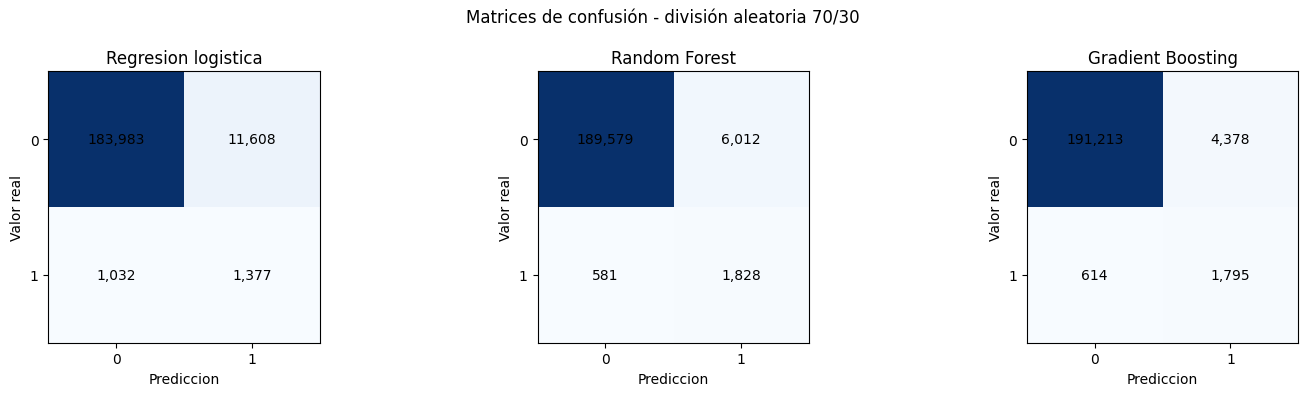

In [13]:
graficar_matrices_confusion(
    metricas_aleatorias,
    "Matrices de confusión - división aleatoria 70/30",
    "matrices_confusion_aleatoria.png"
)


## 4.1 Resultados e interpretación

Gradient Boosting presentó el mejor resultado general en la división aleatoria. Alcanzó F2 de 0.568, Recall de 0.745, Precision de 0.291 y ROC-AUC de 0.980. Random Forest obtuvo el Recall más alto, 0.759, pero su F2 fue menor, 0.523. La Regresión Logística tuvo el desempeño más bajo, con F2 de 0.304.

Los parámetros seleccionados fueron C igual a 0.1 para Regresión Logística, profundidad máxima de 18 para Random Forest y tasa de aprendizaje de 0.08 con 63 hojas para Gradient Boosting. Los umbrales fueron 0.783, 0.381 y 0.848, respectivamente.

La Accuracy fue alta en los tres modelos porque casi todas las observaciones pertenecen a la clase baja. Por sí sola no describe bien el problema. Gradient Boosting redujo los falsos positivos a 4,378, mientras que Random Forest dejó menos falsos negativos, 581.

Un falso positivo representa una zona de señal baja marcada como alta. Puede causar una revisión adicional o una alerta que finalmente no era necesaria. Un falso negativo representa una zona con señal alta que no fue detectada. Este segundo error puede retrasar el monitoreo y aumentar el riesgo ambiental o sanitario. Por esta razón el Recall y F2 tienen más peso que Accuracy para escoger el modelo.


# Ejercicio 5. Validación espacial y temporal

## 5.1 Bloques espaciales

Las coordenadas se reproyectan de WGS 84 a WGS 84 / UTM zona 15N, EPSG:32615. Después se forma una cuadrícula de 1 km por 1 km. Todas las observaciones de un mismo bloque se mantienen juntas durante la validación.


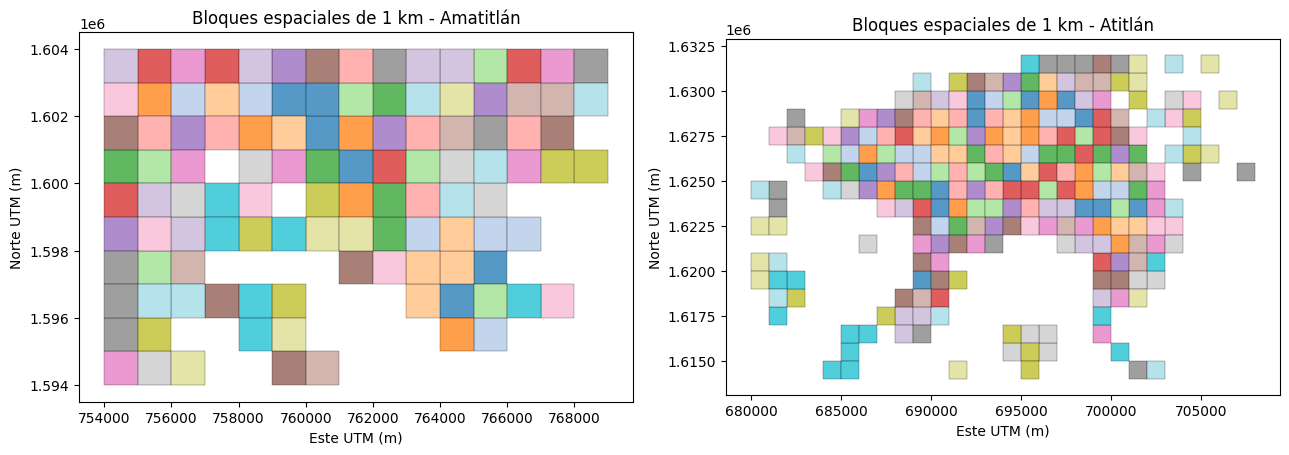

,lago,bloques,minimo,mediana,promedio,maximo
0,Amatitlán,112,1,201.0,2946.428571,22218
1,Atitlán,243,1,1008.0,1358.024691,3208


,count,mean,std,min,25%,50%,75%,max
lago,,,,,,,,
Amatitlán,112.0,2946.428571,5482.575956,1.0,25.75,201.0,2241.75,22218.0
Atitlán,243.0,1358.024691,1282.888731,1.0,7.50,1008.0,2824.00,3208.0


In [14]:
datos_bloques = crear_bloques_espaciales(
    datos,
    tamano_metros=1000
)

estadisticas_bloques, observaciones_bloque = resumir_y_graficar_bloques(
    datos_bloques
)

display(estadisticas_bloques)
display(
    observaciones_bloque.groupby("lago")["observaciones"].describe()
)


### Evaluación del tamaño de bloque

La cuadrícula produjo 112 bloques con observaciones en Amatitlán y 243 en Atitlán, para un total de 355. La mediana fue de 201 observaciones por bloque en Amatitlán y 1,008 en Atitlán. Algunos bloques de borde tuvieron solamente una observación, pero la cantidad total de bloques y la cantidad central de observaciones fueron suficientes para formar cinco grupos. Por eso se mantuvo el tamaño solicitado de 1 km.


## 5.2 GroupKFold espacial

Se usan cinco grupos de validación. Cada bloque aparece completo en entrenamiento o validación, pero nunca se divide entre ambos. Así se reduce la ventaja artificial de tener puntos vecinos en los dos grupos.


In [15]:
metricas_espaciales = validar_modelos_espacialmente(
    datos_bloques=datos_bloques,
    predictores=PREDICTORES,
    modelos=resultado_aleatorio["modelos"],
    umbrales=resultado_aleatorio["umbrales"],
    objetivo="cyano_alta",
    n_splits=5
)

comparacion_validacion = pd.concat([
    metricas_aleatorias,
    metricas_espaciales
], ignore_index=True)

display(comparacion_validacion[[
    "validacion", "modelo", "Accuracy", "Precision", "Recall",
    "F1", "F2", "ROC_AUC", "FP", "FN"
]])


Regresion logistica - bloque espacial 1/5


Regresion logistica - bloque espacial 2/5


Regresion logistica - bloque espacial 3/5


Regresion logistica - bloque espacial 4/5


Regresion logistica - bloque espacial 5/5


...

Gradient Boosting - bloque espacial 2/5


Gradient Boosting - bloque espacial 3/5


Gradient Boosting - bloque espacial 4/5


Gradient Boosting - bloque espacial 5/5


,validacion,modelo,Accuracy,Precision,Recall,F1,F2,ROC_AUC,FP,FN
0,Aleatoria 70/30,Regresion logistica,0.936162,0.106045,0.571606,0.178901,0.304363,0.881570,11608,1032
1,Aleatoria 70/30,Random Forest,0.966702,0.233163,0.758821,0.356718,0.523003,0.974096,6012,581
2,Aleatoria 70/30,Gradient Boosting,0.974788,0.290782,0.745122,0.418317,0.567715,0.979668,4378,614
3,Espacial GroupKFold,Regresion logistica,0.933971,0.103560,0.578135,0.175655,0.301658,0.882463,40191,3388
4,Espacial GroupKFold,Random Forest,0.964917,0.174920,0.506662,0.260058,0.367331,0.938664,19193,3962
5,Espacial GroupKFold,Gradient Boosting,0.973585,0.200713,0.392604,0.265628,0.329584,0.940448,12556,4878


### Resultado de la validación espacial

Random Forest fue el mejor modelo bajo validación espacial, con Recall de 0.507, F2 de 0.367 y ROC-AUC de 0.939. Gradient Boosting obtuvo F2 de 0.330 y la Regresión Logística 0.302.

En Random Forest el Recall bajó de 0.759 a 0.507, una reducción de 0.252. F2 bajó de 0.523 a 0.367 y ROC-AUC bajó de 0.974 a 0.939. La reducción indica que la división aleatoria era optimista porque colocaba observaciones cercanas en entrenamiento y prueba. GroupKFold espacial da una estimación más realista para predecir zonas nuevas.


## 5.3 Validación temporal

La prueba temporal usa las tres fechas más recientes de cada lago. Las fechas anteriores se usan para entrenar. Esta separación mide mejor la capacidad de predecir momentos futuros y evita que una misma fecha aparezca en ambos grupos.


In [16]:
metricas_temporales, fechas_prueba_temporal = validar_modelos_temporalmente(
    datos=datos,
    predictores=PREDICTORES,
    modelos=resultado_aleatorio["modelos"],
    umbrales=resultado_aleatorio["umbrales"],
    objetivo="cyano_alta",
    fechas_prueba_por_lago=3
)

print("Fechas usadas como prueba temporal")
display(fechas_prueba_temporal)
display(metricas_temporales[columnas_metricas])


Fechas usadas como prueba temporal


{'Amatitlán': ['2026-04-13', '2026-04-28', '2026-06-19'],
 'Atitlán': ['2026-04-13', '2026-04-28', '2026-07-22']}

,modelo,Accuracy,Precision,Recall,F1,F2,ROC_AUC,TN,FP,FN,TP,umbral
0,Regresion logistica,0.953089,0.139764,0.210267,0.167915,0.190997,0.698197,170704,5244,3200,852,0.783341
1,Random Forest,0.845667,0.093754,0.675716,0.164662,0.301462,0.859631,149482,26466,1314,2738,0.380659
2,Gradient Boosting,0.949733,0.154017,0.274432,0.197303,0.237323,0.790532,169840,6108,2940,1112,0.848091


### Resultado de la validación temporal

Random Forest conservó el mayor Recall temporal, 0.676, y el mayor F2, 0.301. Sin embargo, su Precision bajó a 0.094 y produjo 26,466 falsos positivos. Frente a la división aleatoria, su Recall bajó 0.083 y F2 bajó 0.222.

Gradient Boosting tuvo F2 de 0.237 y la Regresión Logística 0.191. Las fechas de prueba incluyen el aumento de señal observado en Amatitlán durante junio de 2026. El cambio entre periodos hace que las relaciones aprendidas con fechas anteriores no se mantengan igual. La validación temporal muestra que predecir fechas futuras es más difícil que separar píxeles al azar.


# Ejercicio 6. Generalización entre lagos

Se realizan dos experimentos. El primero entrena con Atitlán y evalúa con Amatitlán. El segundo entrena con Amatitlán y evalúa con Atitlán. La lista de variables y los umbrales se mantienen sin cambios.


In [17]:
metricas_lagos = evaluar_generalizacion_lagos(
    datos=datos,
    predictores=PREDICTORES,
    modelos=resultado_aleatorio["modelos"],
    umbrales=resultado_aleatorio["umbrales"],
    objetivo="cyano_alta"
)

display(metricas_lagos[[
    "entrenamiento", "prueba", "modelo", "Accuracy", "Precision",
    "Recall", "F1", "F2", "ROC_AUC", "FP", "FN"
]])


,entrenamiento,prueba,modelo,Accuracy,Precision,Recall,F1,F2,ROC_AUC,FP,FN
0,Amatitlán,Atitlán,Regresion logistica,0.726333,0.002370,0.479821,0.004717,0.011621,0.669232,90078,232
1,Amatitlán,Atitlán,Random Forest,0.543867,0.001250,0.421525,0.002492,0.006175,0.445613,150266,258
2,Amatitlán,Atitlán,Gradient Boosting,0.943921,0.007687,0.316143,0.015010,0.035029,0.734869,18201,305
3,Atitlán,Amatitlán,Regresion logistica,0.022985,0.022985,1.000000,0.044937,0.105248,0.744080,322415,0
4,Atitlán,Amatitlán,Random Forest,0.447609,0.020566,0.494001,0.039487,0.088149,0.524587,178451,3838
5,Atitlán,Amatitlán,Gradient Boosting,0.108536,0.024760,0.984311,0.048306,0.112484,0.643276,294064,119


## 6.1 Resultados e interpretación

Los modelos no generalizaron de forma adecuada entre lagos. Al entrenar con Amatitlán y evaluar con Atitlán, la mejor F2 fue solamente 0.035 con Gradient Boosting. La Precision fue 0.008 y el Recall 0.316. Al entrenar con Atitlán y evaluar con Amatitlán, Gradient Boosting alcanzó Recall de 0.984, pero clasificó demasiadas zonas como altas: la Precision fue 0.025 y la Accuracy 0.109.

La diferencia de prevalencia es importante. La clase alta representa 2.30 % en Amatitlán y 0.14 % en Atitlán. También cambian la ubicación, el rango de B03, la forma del lago y las condiciones de cada fecha. Como las coordenadas de un lago no se traslapan con las del otro, un patrón espacial aprendido en uno no se puede trasladar directamente. Los resultados apoyan el uso de modelos separados o de más variables ambientales que sean comparables entre lagos.


# Ejercicio 7. Interpretación y explicabilidad

El mejor modelo se selecciona con F2 en la validación espacial. Esta decisión usa la evaluación más realista para zonas nuevas y da prioridad a detectar la clase alta.


Mejor modelo: Random Forest
Umbral: 0.3806586120927587


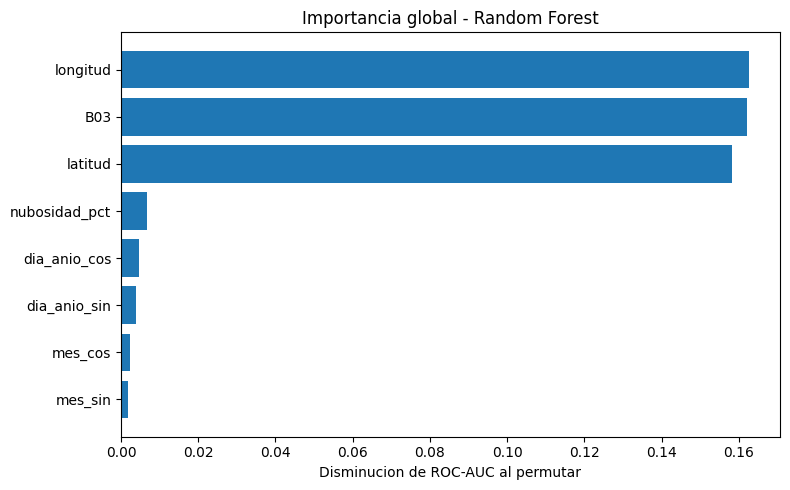

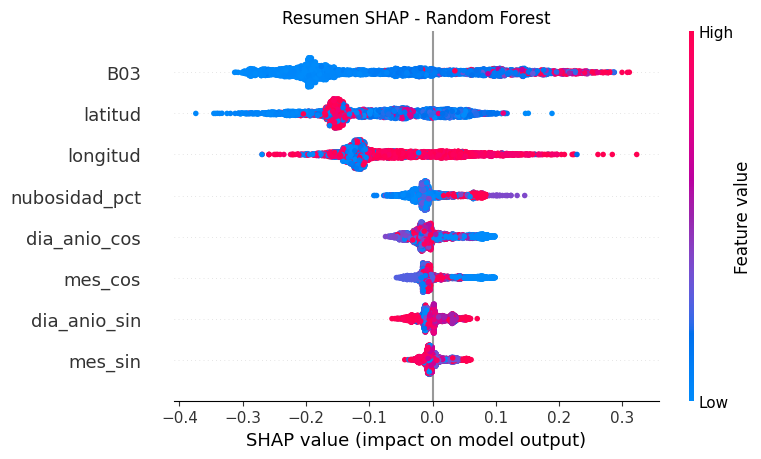

,variable,importancia
0,longitud,0.162545
2,B03,0.162171
1,latitud,0.158344
3,nubosidad_pct,0.006690
7,dia_anio_cos,0.004563
6,dia_anio_sin,0.003851
5,mes_cos,0.002392
4,mes_sin,0.001875


,variable,shap_abs_medio
2,B03,0.145322
1,latitud,0.105959
0,longitud,0.091099
3,nubosidad_pct,0.027347
7,dia_anio_cos,0.026549
5,mes_cos,0.021616
6,dia_anio_sin,0.016868
4,mes_sin,0.012064


In [18]:
mejor_nombre = (
    metricas_espaciales
    .sort_values("F2", ascending=False)
    .iloc[0]["modelo"]
)

mejor_modelo = resultado_aleatorio["modelos"][mejor_nombre]
mejor_umbral = resultado_aleatorio["umbrales"][mejor_nombre]

print("Mejor modelo:", mejor_nombre)
print("Umbral:", mejor_umbral)

X_explicacion = datos[PREDICTORES]
y_explicacion = datos["cyano_alta"]

importancia_global, importancia_shap = explicar_modelo(
    modelo=mejor_modelo,
    X=X_explicacion,
    y=y_explicacion,
    predictores=PREDICTORES,
    nombre_modelo=mejor_nombre,
    random_state=RANDOM_STATE
)

display(importancia_global)
display(importancia_shap)


## 7.1 Interpretación de variables

La importancia por permutación muestra tres variables principales: longitud, B03 y latitud. Cada una redujo el ROC-AUC aproximadamente 0.16 al ser alterada. Las variables de nubosidad y tiempo tuvieron una contribución mucho menor.

SHAP coloca B03 como la variable con mayor efecto promedio. Los valores altos de B03 tienden a aumentar la predicción de clase alta y los valores bajos tienden a reducirla. Esto puede relacionarse con cambios en la reflectancia verde del agua, aunque también puede responder a turbidez u otros materiales.

Latitud y longitud muestran efectos no lineales. En general, latitudes más bajas aumentan la predicción y latitudes más altas la reducen, lo que también separa Amatitlán de Atitlán. La longitud identifica zonas locales, pero el sentido del efecto cambia entre sectores. Esto confirma que una parte importante del modelo depende de la ubicación y explica la pérdida de desempeño al cambiar de lago o de bloque espacial.

La nubosidad alta presenta un aumento pequeño en algunas predicciones. Las variables de mes y día del año tienen efectos mixtos y menores. No se interpretan como causas directas, sino como patrones presentes en las fechas analizadas.


# Ejercicio 8. Mapas predictivos

El mejor modelo calcula la probabilidad de clase alta para las 660,000 observaciones. Los mapas usan cuatro niveles: muy baja de 0 a 0.25, baja de 0.25 a 0.50, alta de 0.50 a 0.75 y muy alta de 0.75 a 1. También se muestra la ubicación de falsos positivos y falsos negativos.


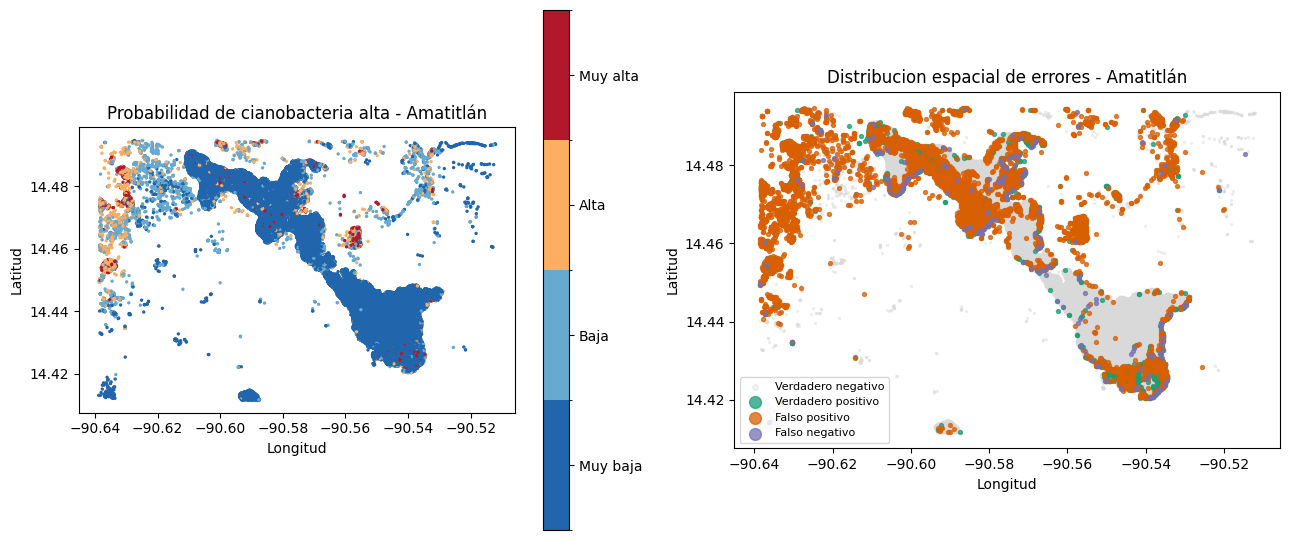

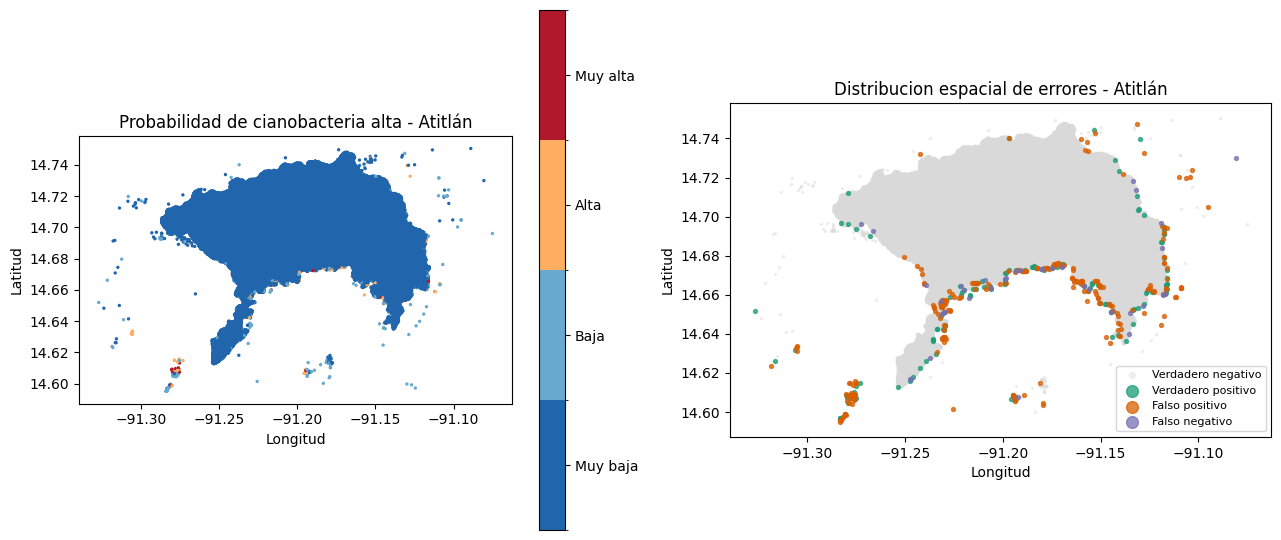

,lago,error,observaciones
0,Amatitlán,Falso negativo,513
1,Amatitlán,Falso positivo,18670
2,Amatitlán,Verdadero negativo,303745
3,Amatitlán,Verdadero positivo,7072
4,Atitlán,Falso negativo,99
5,Atitlán,Falso positivo,661
6,Atitlán,Verdadero negativo,328893
7,Atitlán,Verdadero positivo,347


Bloques con más errores


error,lago,bloque_espacial,Falso negativo,Falso positivo,Verdadero negativo,Verdadero positivo,errores
18,Amatitlán,Amatitlán_755_1602,4,1640,295,277,1644
76,Amatitlán,Amatitlán_763_1600,2,1323,360,423,1325
62,Amatitlán,Amatitlán_761_1601,48,1133,10945,237,1181
17,Amatitlán,Amatitlán_755_1601,4,1080,160,653,1084
54,Amatitlán,Amatitlán_760_1600,46,776,12246,252,822
255,Atitlán,Atitlán_696_1623,2,50,1941,10,52
137,Atitlán,Atitlán_685_1615,0,49,27,21,49
186,Atitlán,Atitlán_690_1620,5,44,1114,7,49
187,Atitlán,Atitlán_690_1621,1,34,1828,5,35
276,Atitlán,Atitlán_698_1622,3,21,1835,10,24


In [19]:
probabilidades_completas = mejor_modelo.predict_proba(
    datos[PREDICTORES]
)[:, 1]

predicciones_mapa, resumen_errores = generar_mapas_predictivos(
    datos=datos,
    probabilidades=probabilidades_completas,
    umbral=mejor_umbral,
    random_state=RANDOM_STATE
)

display(resumen_errores)

errores_bloque = (
    datos_bloques[["lago", "bloque_espacial", "x_utm", "y_utm"]]
    .assign(error=predicciones_mapa["error"].to_numpy())
    .groupby(["lago", "bloque_espacial", "error"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for columna in ["Falso positivo", "Falso negativo", "Verdadero positivo", "Verdadero negativo"]:
    if columna not in errores_bloque:
        errores_bloque[columna] = 0

errores_bloque["errores"] = (
    errores_bloque["Falso positivo"]
    + errores_bloque["Falso negativo"]
)

print("Bloques con más errores")
display(
    errores_bloque
    .sort_values(["lago", "errores"], ascending=[True, False])
    .groupby("lago")
    .head(5)
)


## 8.1 Comparación espacial e interpretación de errores

El mapa de Atitlán está dominado por probabilidades muy bajas, en acuerdo con la baja frecuencia de la clase alta. Las zonas con probabilidad alta aparecen principalmente cerca de bordes del sur y del este. El mapa de la Parte I también mostró un nivel general bajo, aunque algunas señales locales del oeste no fueron reproducidas de manera constante.

Amatitlán presenta más zonas con probabilidad alta y muy alta, sobre todo en sectores del norte, oeste y centro. Este patrón tiene mayor relación con el mapa de la fecha pico de la Parte I, que mostró una señal más extensa que en Atitlán. Aun así, el modelo extiende la alerta a muchos puntos de señal baja.

En Amatitlán se obtuvieron 7,072 verdaderos positivos, 513 falsos negativos y 18,670 falsos positivos. Los errores se concentran en varios bloques del norte, oeste y centro, especialmente en los bloques UTM 755_1602, 763_1600 y 761_1601. En Atitlán se obtuvieron 347 verdaderos positivos, 99 falsos negativos y 661 falsos positivos. Sus errores aparecen principalmente cerca de orillas y en pequeños grupos fuera del cuerpo principal.

La mayor dificultad ocurre en bordes y zonas con píxeles aislados. Parte de este patrón puede venir de la máscara NDWI, que conserva algunos puntos con apariencia de agua fuera de la forma principal del lago. También muestra que el modelo confunde señal verde y ubicación con el índice alto en sectores específicos.


# Ejercicio 9. Análisis y conclusiones

El modelo puede servir como herramienta inicial para priorizar zonas que necesitan revisión, pero no tiene capacidad suficiente para usarse como sistema autónomo de alerta. Random Forest fue el modelo más adecuado al considerar el costo ambiental de los falsos negativos. En la validación espacial obtuvo Recall de 0.507, F2 de 0.367 y ROC-AUC de 0.939. En la validación temporal su Recall fue 0.676, pero la Precision fue solamente 0.094.

La comparación entre validaciones es la evidencia principal. El resultado aleatorio fue más alto porque mezcló observaciones cercanas. Al separar bloques, Random Forest perdió 0.252 de Recall. Los experimentos entre lagos fueron todavía más débiles y mostraron que un modelo entrenado en un lago no se traslada bien al otro.

Las principales limitaciones son el fuerte desbalance, solamente 22 fechas, diferencias grandes entre lagos y falta de mediciones físicas. La variable respuesta proviene de un umbral espectral y no de conteos de cianobacterias en campo. La resolución de 20 metros, la nubosidad, los píxeles de borde y la máscara basada en NDWI también agregan error. Además, al excluir las bandas usadas para construir la respuesta, B03 queda como la única banda espectral del modelo base y no representa por sí sola todos los procesos ambientales.

El modelo podría mejorar con mediciones de células, clorofila-a y toxinas tomadas el mismo día que el satélite. También serían útiles temperatura del agua y del aire, precipitación, viento, nutrientes, turbidez, profundidad, entradas de ríos y circulación del agua. Se necesitan más fechas en distintas estaciones, límites oficiales de los lagos y una validación con campañas de campo. Con estos datos se podrían construir modelos separados por lago y comprobar si las alertas representan floraciones reales.


# Referencias

Sentinel Hub. Maximum Peak Height Bloom Index. Custom scripts for Sentinel-2.  
https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/maximum_peak_height_bloom_index/

Matthews, M. W., Bernard, S. y Robertson, L. 2012. An algorithm for detecting trophic status, cyanobacterial dominance, surface scums and floating vegetation in inland and coastal waters. Remote Sensing of Environment, 124, 637 a 652.

Gower, J., King, S. y Goncalves, P. 2008. Global monitoring of plankton blooms using MERIS MCI. International Journal of Remote Sensing, 29, 6209 a 6216.

Hu, C. 2009. A novel ocean color index to detect floating algae in the global oceans. Remote Sensing of Environment, 113, 2118 a 2129.

Roberts, D. R. et al. 2017. Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. Ecography, 40, 913 a 929.
